<a href="https://colab.research.google.com/github/Uzema/dsp-seminars/blob/nikolaev_lab3/seminars/3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

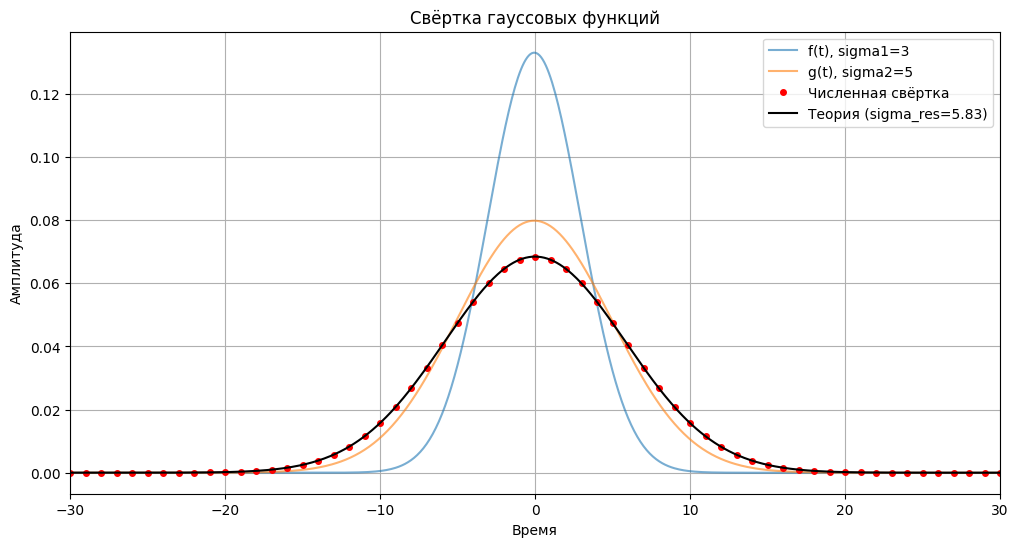

Среднеквадратичная ошибка (MSE): 3.67e-30


In [62]:
from scipy.signal.windows import gaussian

sigma1 = 3
sigma2 = 5
fs = 10
t_range = 50

t = np.arange(-t_range, t_range, 1/fs)
M = len(t)
dt = 1/fs

f = gaussian(M, std=sigma1 * fs)
g = gaussian(M, std=sigma2 * fs)

# нормировка
f /= (np.sum(f) * dt)
g /= (np.sum(g) * dt)

numerical_conv = np.convolve(f, g, mode='same') * dt

sigma_res = np.sqrt(sigma1**2 + sigma2**2)
theoretical_conv = (1 / (np.sqrt(2 * np.pi) * sigma_res)) * np.exp(-t**2 / (2 * sigma_res**2))

plt.figure(figsize=(12, 6))
plt.plot(t, f, label=f'f(t), sigma1={sigma1}', alpha=0.6)
plt.plot(t, g, label=f'g(t), sigma2={sigma2}', alpha=0.6)
plt.plot(t, numerical_conv, 'ro', markersize=4, markevery=10, label='Численная свёртка')
plt.plot(t, theoretical_conv, 'k-', label=f'Теория (sigma_res={sigma_res:.2f})')

plt.title('Свёртка гауссовых функций')
plt.xlabel('Время')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)
plt.xlim(-30, 30)
plt.show()

mse = np.mean((numerical_conv - theoretical_conv)**2)
print(f"Среднеквадратичная ошибка (MSE): {mse:.2e}")

**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

Чем больше $\sigma$, тем шире станет функция и ниже станет ее пик. (из-за того что мы работаем с нормированными функциями, площадь под которыми равна 1)

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

<Figure size 1500x600 with 0 Axes>

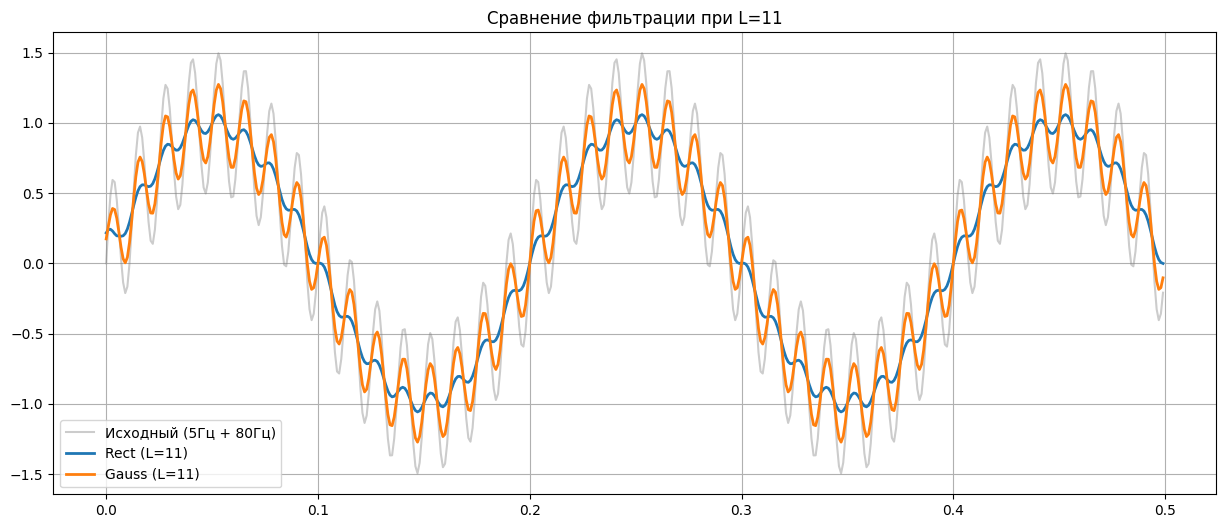

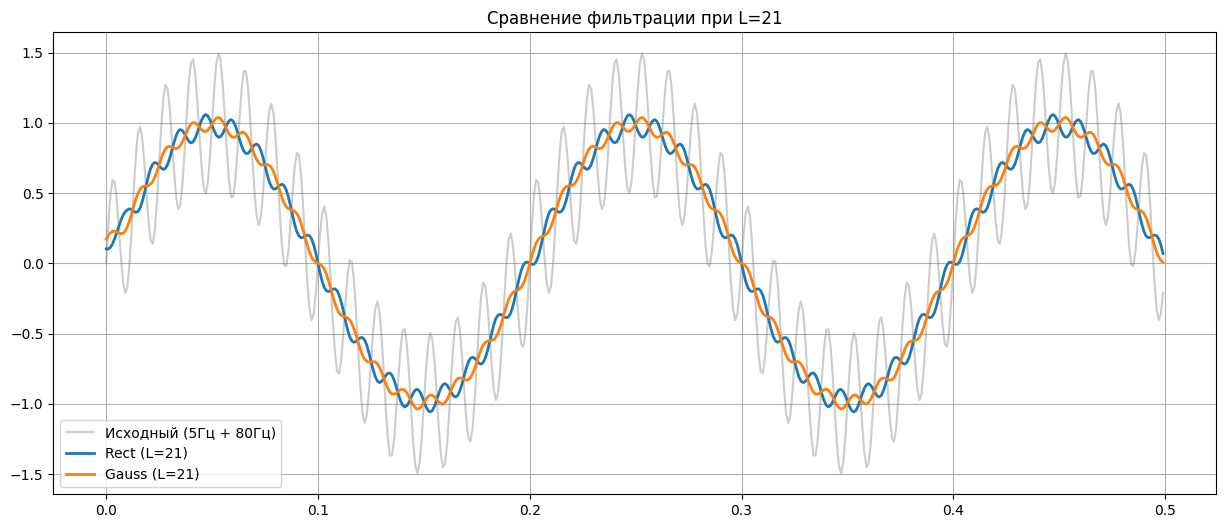

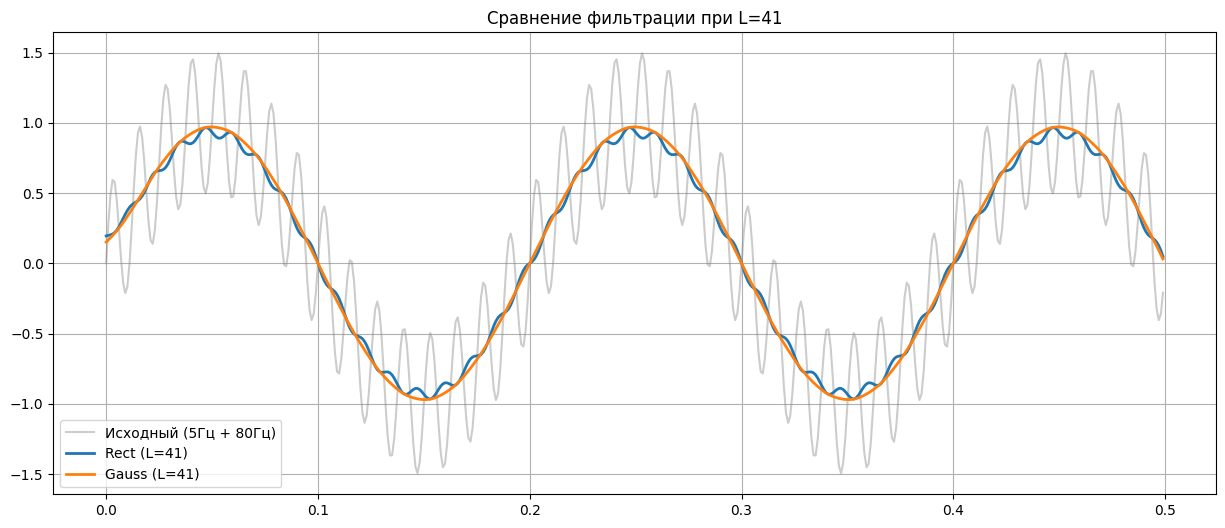

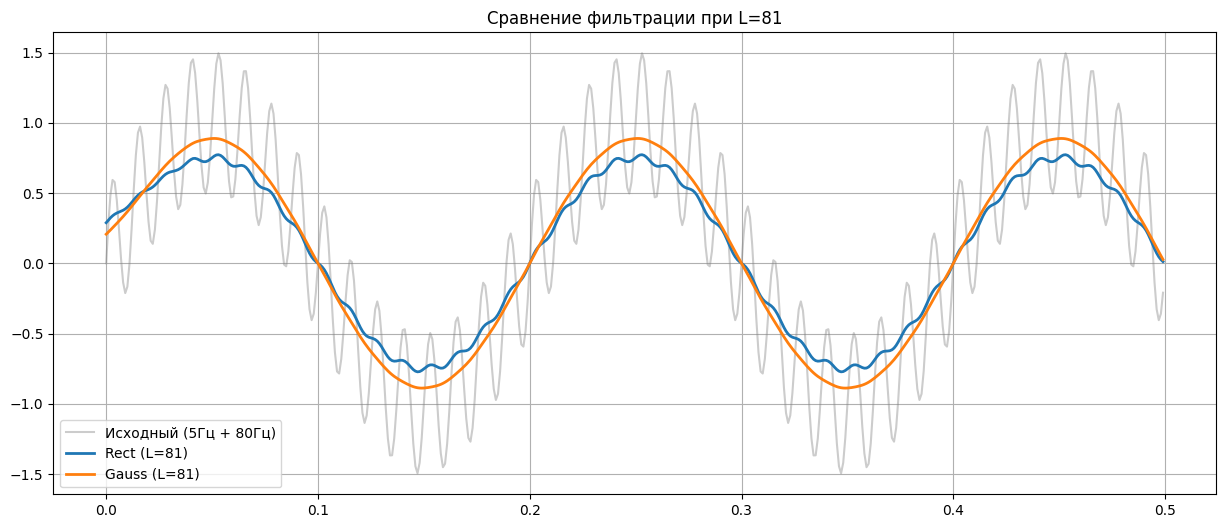

L     | Тип        | Амп. 5 Гц  | Амп. 80 Гц
---------------------------------------------
11    | Rect       | 0.9951     | 0.0678    
11    | Gauss      | 0.9978     | 0.2804    
21    | Rect       | 0.9822     | 0.0800    
21    | Gauss      | 0.9922     | 0.0502    
41    | Rect       | 0.9330     | 0.0367    
41    | Gauss      | 0.9704     | 0.0005    
81    | Rect       | 0.7542     | 0.0254    
81    | Gauss      | 0.8891     | 0.0028    


In [63]:
# 1. Генерация сигнала
fs = 1000
T = 2
t = np.linspace(0, T, fs * T, endpoint=False)
f1, f2 = 5, 80
A1, A2 = 1.0, 0.5

# Исходный сигнал
sig = A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.sin(2 * np.pi * f2 * t)

def analyze_filtering(L):
    # 2. Прямоугольное окно
    rect_win = signal.windows.boxcar(L)
    rect_win /= np.sum(rect_win)  # Нормализация

    # 3. Гауссовское окно
    gauss_win = signal.windows.gaussian(L, std=L/5)
    gauss_win /= np.sum(gauss_win)  # Нормализация

    # 4. Фильтрация (свёртка)
    sig_rect = np.convolve(sig, rect_win, mode='same')
    sig_gauss = np.convolve(sig, gauss_win, mode='same')

    return sig_rect, sig_gauss

# Для демонстрации возьмем L=21
L = 21
sig_rect, sig_gauss = analyze_filtering(L)

# 5. Визуализация первых 0.5 секунд
plt.figure(figsize=(15, 6))
zoom = t < 0.5
# plt.plot(t[zoom], sig[zoom], label='Исходный (5Гц + 80Гц)', alpha=0.4, color='gray')
# plt.plot(t[zoom], sig_rect[zoom], label=f'Rect (L={L})', linewidth=2)
# plt.plot(t[zoom], sig_gauss[zoom], label=f'Gauss (L={L})', linewidth=2)

# plt.title(f'Сравнение фильтрации при L={L}')
# plt.legend()
# plt.grid(True)
# plt.show()

def get_amplitude_at(s, fs, freq_target):
    N = len(s)
    X = np.fft.fft(s)
    freqs = np.fft.fftfreq(N, d=1/fs)
    idx = np.argmin(np.abs(freqs - freq_target))
    return (2.0 / N) * np.abs(X[idx])

L_list = [11, 21, 41, 81]

for L in L_list:
    sr, sg = analyze_filtering(L)
    plt.figure(figsize=(15, 6))
    plt.plot(t[zoom], sig[zoom], label='Исходный (5Гц + 80Гц)', alpha=0.4, color='gray')
    plt.plot(t[zoom], sr[zoom], label=f'Rect (L={L})', linewidth=2)
    plt.plot(t[zoom], sg[zoom], label=f'Gauss (L={L})', linewidth=2)
    plt.title(f'Сравнение фильтрации при L={L}')
    plt.legend()
    plt.grid(True)
    plt.show()

print(f"{'L':<5} | {'Тип':<10} | {'Амп. 5 Гц':<10} | {'Амп. 80 Гц':<10}")
print("-" * 45)

for L in L_list:
    sr, sg = analyze_filtering(L)
    for name, res_sig in [("Rect", sr), ("Gauss", sg)]:
        a5 = get_amplitude_at(res_sig, fs, 5)
        a80 = get_amplitude_at(res_sig, fs, 80)
        print(f"{L:<5} | {name:<10} | {a5:<10.4f} | {a80:<10.4f}")


**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

- При малых L прямоугольное окно дает лучшее подавление высокой частоты, но при более высоких значениях L гауссовское окно дает лучше результат.
- При длине прямоугольного L=41, и при длине гауссовского L=21.
- Для обоих окон L=81, при котором амплитуда низкой частоты уменьшается более чем на 10% (<0.9). При увеличении длины окна проявляется подавление амплитуд низких частот.

## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

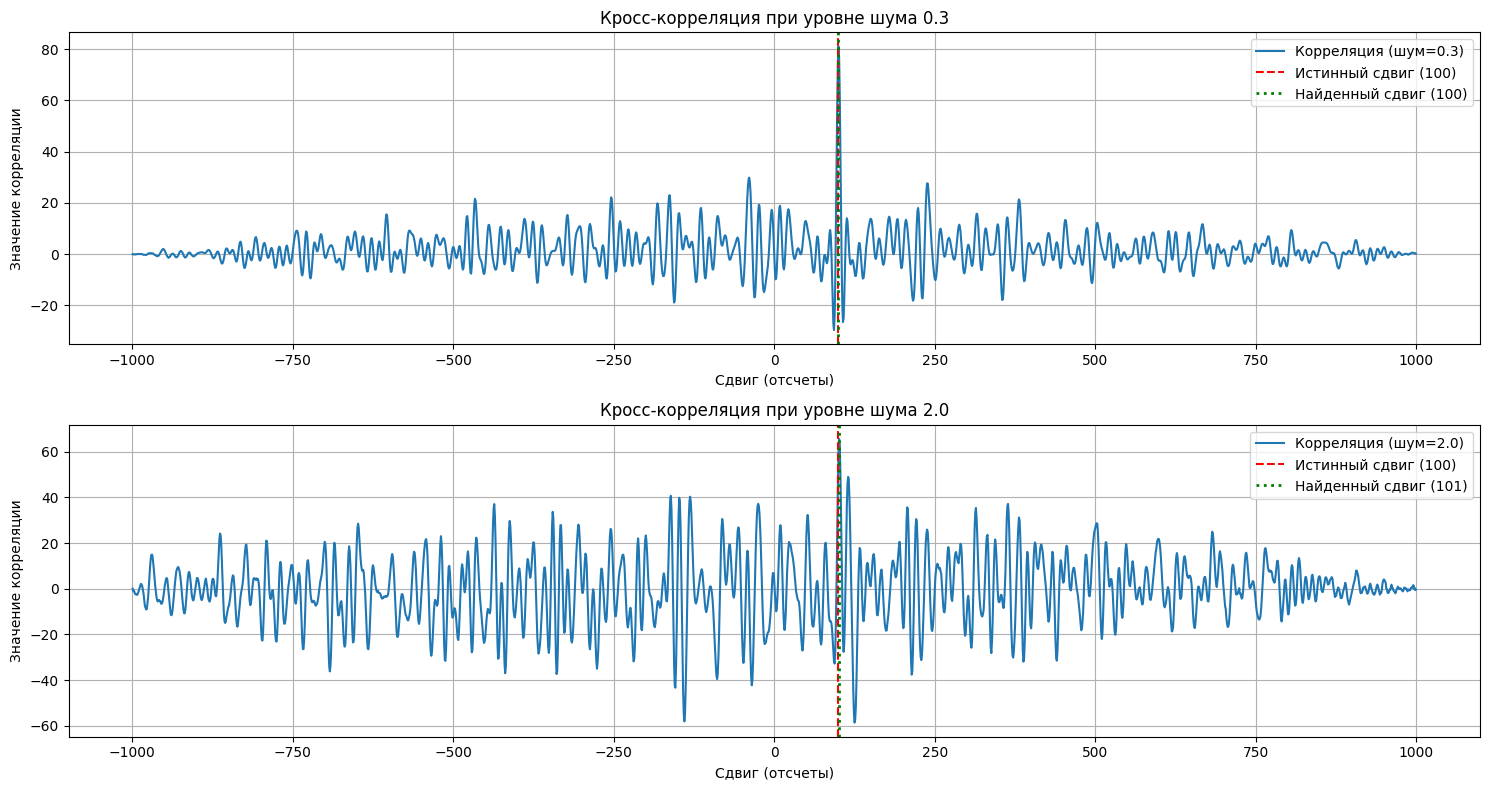

noise level = 0.1, delay_est = 100
noise level = 0.2, delay_est = 100
noise level = 0.30000000000000004, delay_est = 100
noise level = 0.4, delay_est = 100
noise level = 0.5, delay_est = 100
noise level = 0.6, delay_est = 100
noise level = 0.7000000000000001, delay_est = 100
noise level = 0.8, delay_est = 100
noise level = 0.9, delay_est = 100
noise level = 1.0, delay_est = 100
noise level = 1.1, delay_est = 100
noise level = 1.2000000000000002, delay_est = 100
noise level = 1.3000000000000003, delay_est = 99
noise level = 1.4000000000000001, delay_est = 100
noise level = 1.5000000000000002, delay_est = 100
noise level = 1.6, delay_est = 99
noise level = 1.7000000000000002, delay_est = 100
noise level = 1.8000000000000003, delay_est = 100
noise level = 1.9000000000000001, delay_est = 100
noise level = 2.0, delay_est = 100
noise level = 2.1, delay_est = 101
noise level = 2.2, delay_est = -179
noise level = 2.3000000000000003, delay_est = -311
noise level = 2.4000000000000004, delay_est 

In [64]:
# 1. Параметры
fs = 1000
T = 1.0
t = np.linspace(0, T, int(fs*T), endpoint=False)
N = len(t)
delay = 100  # Истинная задержка в отсчетах

# Генерация сигнала x (сумма 100 синусоид)
np.random.seed(42)
freqs = np.random.uniform(10, 100, 100)
amps = np.random.uniform(0.5, 1.5, 100)
phases = np.random.uniform(0, 2*np.pi, 100)

x = np.zeros_like(t)
for f, a, p in zip(freqs, amps, phases):
    x += a * np.sin(2 * np.pi * f * t + p)

# Нормализация x в [-1, 1]
x = 2 * (x - np.min(x)) / (np.max(x) - np.min(x)) - 1

# 2. Создание зашумленного сигнала y со сдвигом
# Сдвигаем x на delay отсчетов (заполняем начало нулями)
y_clean = np.zeros_like(x)
y_clean[delay:] = x[:-delay]

def get_delay_estimation(noise_lvl):
    noise = noise_lvl * np.random.randn(N)
    y = y_clean + noise

    # 3. Кросс-корреляция
    corr = np.correlate(y, x, mode='full')
    lags = np.arange(-N + 1, N)

    idx_max = np.argmax(corr)
    delay_est = lags[idx_max]

    return lags, corr, delay_est

# 4-5. Эксперимент и визуализация
noise_levels = [0.3, 2.0]
plt.figure(figsize=(15, 8))

for i, nl in enumerate(noise_levels):
    lags, corr, est = get_delay_estimation(nl)

    plt.subplot(2, 1, i+1)
    plt.plot(lags, corr, label=f'Корреляция (шум={nl})')
    plt.axvline(delay, color='r', linestyle='--', label=f'Истинный сдвиг ({delay})')
    plt.axvline(est, color='g', linestyle=':', label=f'Найденный сдвиг ({est})', linewidth=2)

    plt.title(f'Кросс-корреляция при уровне шума {nl}')
    plt.xlabel('Сдвиг (отсчеты)')
    plt.ylabel('Значение корреляции')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

for nl in np.arange(0.1, 3.1, 0.1):
  lags, corr, est = get_delay_estimation(nl)
  print(f'noise level = {nl}, delay_est = {est}')

**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

- Точность оценки остается неизменной пока мощность шума не превысит определенный порог. В моем случае вычисленная задержка отличается от истинной более чем на 10% при уровне шума 2.2
При уровне шума <2.2 почти не возникает ошибок, если я правильно понял о чем вопрос.
- т.к. мощность шума становится настолько велика, что случайные комбинации чисел в массиве noise будут больше похожи на сигнал, нежели чем сам сигнал.

## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

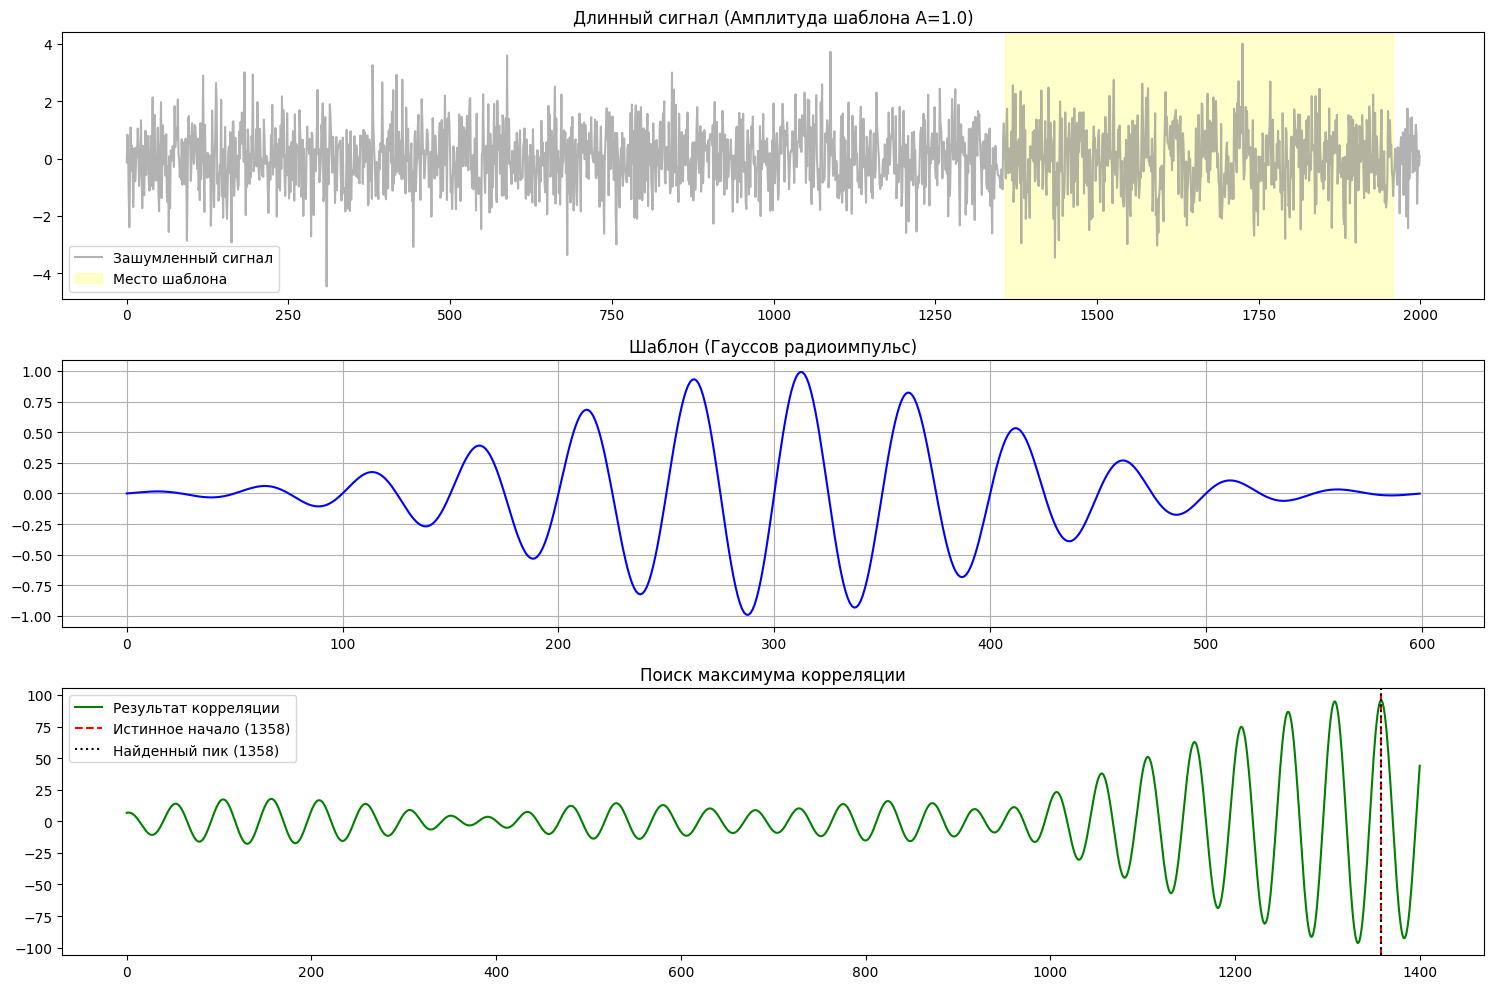

Амп. A   | Найдено  | Ошибка  
------------------------------
0.2      | 1154     | -204    
0.3      | 1155     | -203    
0.4      | 1257     | -101    
0.5      | 1308     | -50     
0.6      | 1308     | -50     
0.7      | 1308     | -50     
0.8      | 1308     | -50     
0.9      | 1358     | 0       
1.0      | 1358     | 0       
1.1      | 1358     | 0       
1.2      | 1358     | 0       
1.3      | 1358     | 0       
1.4      | 1358     | 0       
2.0      | 1358     | 0       
5.0      | 1358     | 0       


In [65]:
# 1. Параметры
fs = 1000
sigma = 100
f_target = 20
L_temp = 6 * sigma # Длина шаблона 600 отсчетов

# Создаем шаблон
t_temp = np.arange(-L_temp//2, L_temp//2)
gauss_env = np.exp(-t_temp**2 / (2 * sigma**2))
sine_wave = np.sin(2 * np.pi * f_target * t_temp / fs)
template = gauss_env * sine_wave

# 2. Создание длинного сигнала
N_long = 2000
long_signal_base = np.random.randn(N_long) # Шум с единичной амплитудой (std=1)

# Случайная позиция для вставки
true_pos = np.random.randint(0, N_long - L_temp)

def run_experiment(A):
    # Копируем шум и вставляем шаблон с амплитудой A
    long_signal = long_signal_base.copy()
    long_signal[true_pos : true_pos + L_temp] += A * template

    # 3. Кросс-корреляция
    corr = np.correlate(long_signal, template, mode='valid')
    est_pos = np.argmax(corr)

    return long_signal, corr, est_pos

# 4. Визуализация для SNR (A = 1.0)
A_test = 1.0
sig, correlation, found_pos = run_experiment(A_test)

plt.figure(figsize=(15, 10))

# Длинный сигнал
plt.subplot(3, 1, 1)
plt.plot(sig, color='gray', alpha=0.6, label='Зашумленный сигнал')
plt.axvspan(true_pos, true_pos + L_temp, color='yellow', alpha=0.2, label='Место шаблона')
plt.title(f'Длинный сигнал (Амплитуда шаблона A={A_test})')
plt.legend()

# Шаблон
plt.subplot(3, 1, 2)
plt.plot(template, color='blue')
plt.title('Шаблон (Гауссов импульс)')
plt.grid(True)

# Результат корреляции
plt.subplot(3, 1, 3)
plt.plot(correlation, color='green', label='Результат корреляции')
plt.axvline(true_pos, color='red', linestyle='--', label=f'Истинное начало ({true_pos})')
plt.axvline(found_pos, color='black', linestyle=':', label=f'Найденный пик ({found_pos})')
plt.title('Поиск максимума корреляции')
plt.legend()

plt.tight_layout()
plt.show()

# 5. Тест разных SNR
print(f"{'Амп. A':<8} | {'Найдено':<8} | {'Ошибка':<8}")
print("-" * 30)
sequence = np.concatenate([np.arange(0.2, 1.5, 0.1), [2.0, 5.0]])
for a in sequence:
    _, _, est = run_experiment(a)
    error = est - true_pos
    print(f"{a:<8.1f} | {est:<8} | {error:<8}")

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

При SNR <0.9 результаты измерения резко ухудшаются




## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [66]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

--2026-04-15 22:09:19--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav [following]
--2026-04-15 22:09:20--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6990446 (6.7M) [audio/wav]
Saving to: ‘full_audio.wav’

full_audio.wav      100%[===================>]   6.67M  --.-KB/s    in 0.02s   

2026-04-15 22:09:20 (353 MB/s) - ‘full_audio.wav’ saved [699044

/tmp/ipykernel_3244/3030691395.py:5: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_full, data_full = wavfile.read('full_audio.wav')
/tmp/ipykernel_3244/3030691395.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_frag, data_frag = wavfile.read('fragment.wav')


44100 44100
(873764, 2) (56401, 2)
Отсчёт: 279235
Время: 6.332 сек.


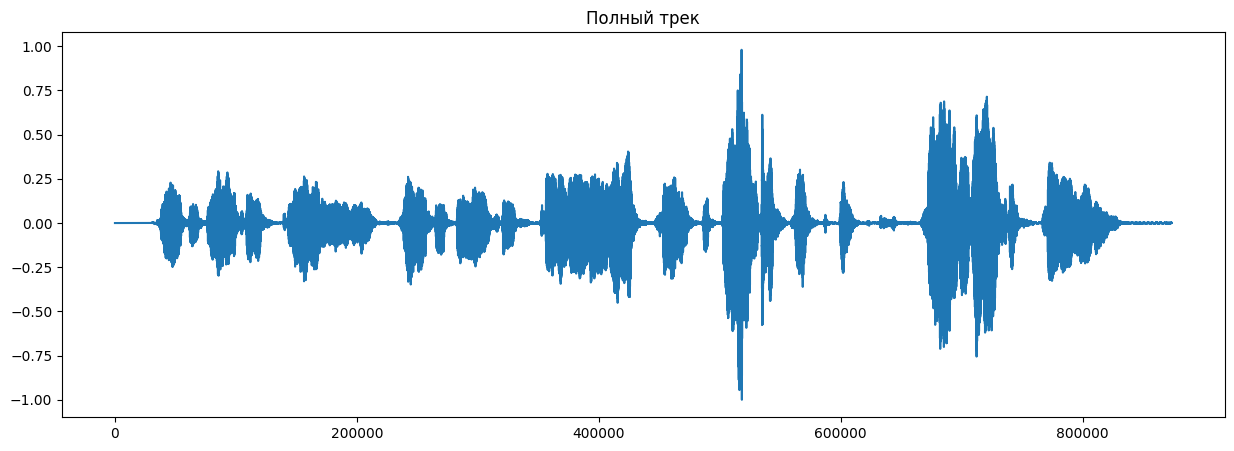

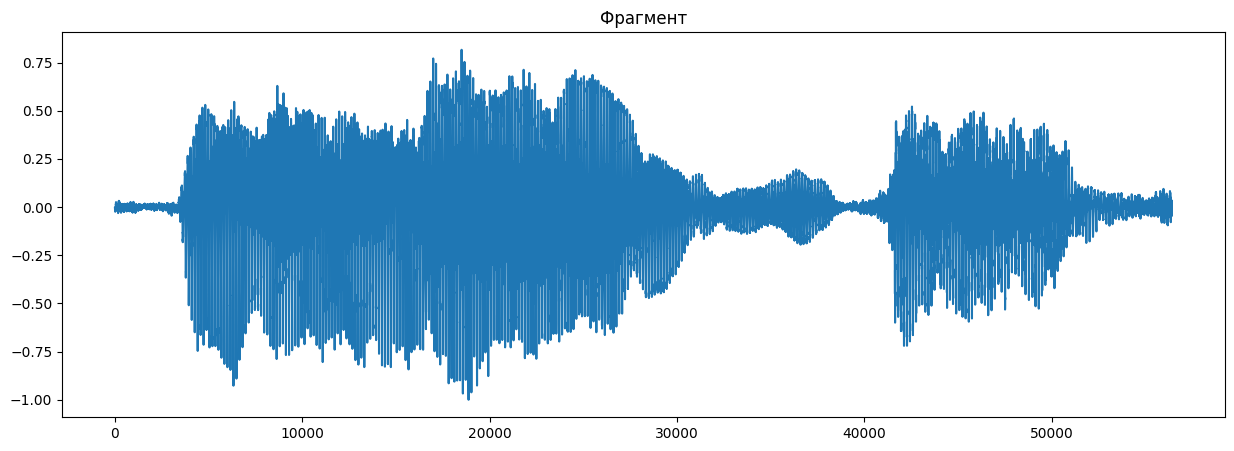

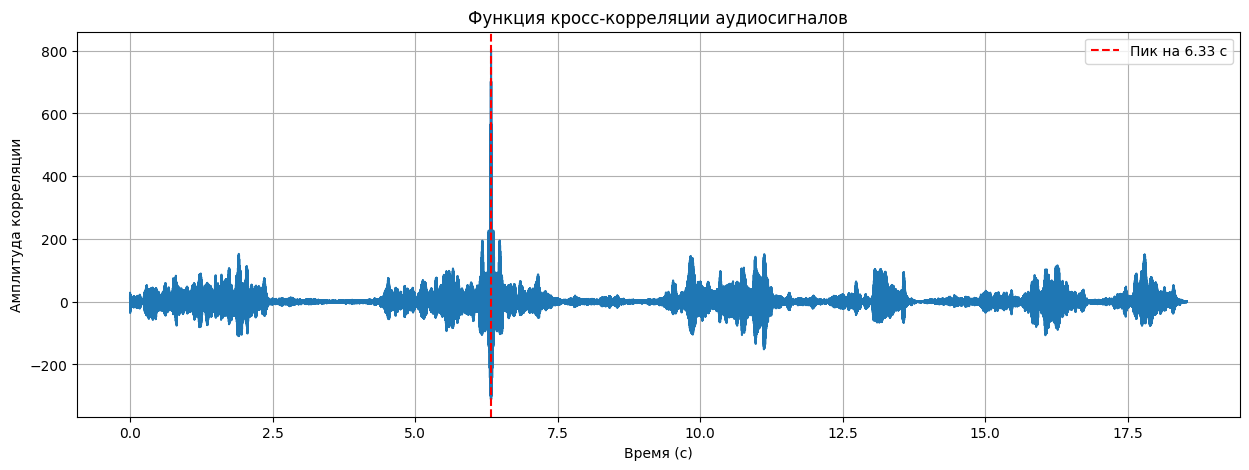

Оригинальный фрагмент:


Вырезанный участок из полного файла:


In [71]:
from scipy.io import wavfile
from IPython.display import Audio, display

# 1. Загрузка файлов
fs_full, data_full = wavfile.read('full_audio.wav')
fs_frag, data_frag = wavfile.read('fragment.wav')

print(fs_full, fs_frag)
print(data_full.shape, data_frag.shape)

audio = data_full[:,0]
fragment = data_frag[:,0]

# Нормализация
audio = audio / np.max(np.abs(audio))
fragment = fragment / np.max(np.abs(fragment))

# 2. Кросс-корреляция
correlation = np.correlate(audio, fragment, mode='valid')

# 3. Поиск позиции
best_idx = np.argmax(np.abs(correlation))
time_offset = best_idx / fs_full

print(f"Отсчёт: {best_idx}")
print(f"Время: {time_offset:.3f} сек.")

# 4. Визуализация
plt.figure(figsize=(15, 5))
plt.title('Полный трек')
plt.plot(audio)
plt.show()

plt.figure(figsize=(15, 5))
plt.title('Фрагмент')
plt.plot(fragment)
plt.show()


plt.figure(figsize=(15, 5))
plt.plot(np.linspace(0, len(correlation)/fs_full, len(correlation)), correlation)
plt.axvline(time_offset, color='r', linestyle='--', label=f'Пик на {time_offset:.2f} с')
plt.title('Функция кросс-корреляции аудиосигналов')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда корреляции')
plt.legend()
plt.grid(True)
plt.show()

# 5. Проверка результата
found_segment = audio[best_idx : best_idx + len(fragment)]

print("Оригинальный фрагмент:")
display(Audio(fragment, rate=fs_frag))

print("Вырезанный участок из полного файла:")
display(Audio(found_segment, rate=fs_full))

**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

- Нормализация сигналов дает фокусироватся на форме сигнала, а не на амплитуде. Иначе громкие звуки могут сильно повлиять при вычислениях.
- 5 раз. \
Не всегда удается его определить, потому что слово может быть произнесено с другой интонацией, иметь шумы и т.д. \
Да, они возникают. Это всплески корреляции на участках, которые случайно похожи по частотному составу на фрагмент.
- Все равно будет возвращен какой-то результат, наиболее похожий на исходный.